# 01 – Audio Basics

In this notebook, we explore the basic structure of audio files and learn how to load, inspect, and visualize a short audio signal.

## Goals

By the end of this notebook, we can:

- load an audio file with Python
- inspect sample rate and duration
- visualize the waveform
- listen to the audio inside the notebook

> Note: All examples are based on a single short audio file for demonstration purposes.

In [15]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd

We use `librosa` for audio loading and analysis, `matplotlib` for plotting, and `IPython.display` to play audio directly in the notebook.

### Working with MP3 files

Audio files are often stored in compressed formats like MP3.  
For analysis, however, it is common to work with uncompressed formats such as WAV.

When loading an MP3 file with `librosa`, the audio is automatically decoded into a raw waveform representation (similar to WAV format).  

This means we can work with MP3 files directly without manually converting them to WAV.

For large-scale projects, converting to WAV beforehand can improve performance, but for this project it is not necessary.

## 1. Load an audio file

First, we define the path to one audio file from our dataset.

In [16]:
audio_path = Path("../data/raw/test_audio.mp3")
print(audio_path)
print("Exists:", audio_path.exists())

../data/raw/test_audio.mp3
Exists: True


The output should be `True`. This confirms that Python can find the audio file.

In [17]:
y, sr = librosa.load(audio_path, sr=None, mono=True)

print("Sampling rate:", sr)
print("Signal shape:", y.shape)
print("Duration in seconds:", len(y) / sr)

Sampling rate: 24000
Signal shape: (699840,)
Duration in seconds: 29.16


The sample rate tells us how many audio samples are stored per second.  
The duration is calculated from the number of samples and the sample rate.

In [18]:
y[:10] # first 10 samples

array([ 0.0000000e+00, -4.0201035e-13,  3.2498098e-13,  1.5749858e-12,
        5.5020501e-13, -1.1457372e-13,  1.2931778e-13,  5.8480130e-13,
        1.5366532e-12, -2.8756793e-13], dtype=float32)

The loaded audio signal is stored as a NumPy array of floating point values between -1 and 1.

## 2. Listen to the audio

Before analyzing the signal visually, it is useful to listen to it.

In [19]:
ipd.Audio(y, rate=sr)

## 3. Waveform

The waveform is a time-domain representation of the audio signal.  
It shows how the amplitude changes over time.

Louder parts correspond to larger amplitude values.

This gives a first impression of the signal structure, such as loud and quiet sections.

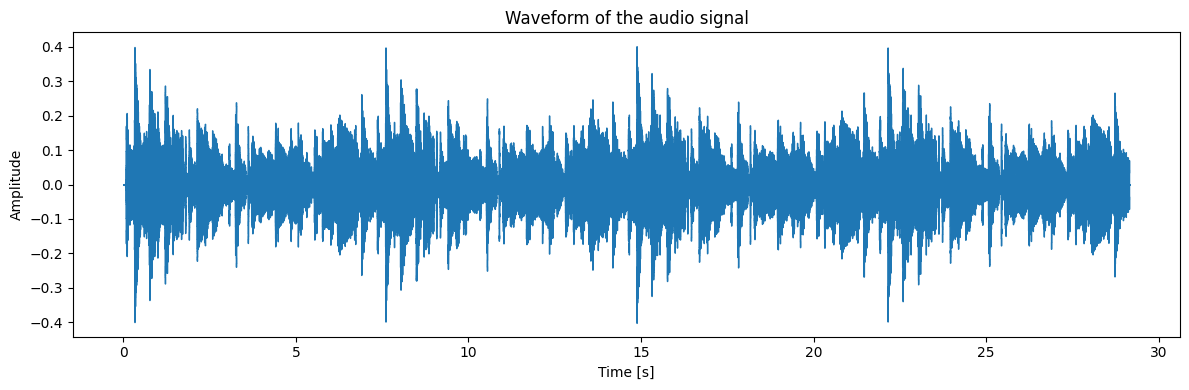

In [20]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of the audio signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## 4. Short-Time Fourier Transform (STFT)

To analyze the frequency content of the signal over time, we compute the Short-Time Fourier Transform (STFT).

The STFT splits the audio signal into small overlapping frames and applies the Fourier Transform to each frame.  
This allows us to see how the frequency content evolves over time.

Each column of the STFT represents the frequency content of a short time window.

In [21]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

print("STFT shape:", D.shape)
print("Spectrogram shape:", S_db.shape)

STFT shape: (1025, 1367)
Spectrogram shape: (1025, 1367)


The result is a complex-valued matrix representing both magnitude and phase.  
For visualization, we convert the magnitude to a logarithmic (decibel) scale.

## 5. Spectrogram

A spectrogram is a visual representation of the frequency content of a signal over time.

- x-axis: time  
- y-axis: frequency  
- color: amplitude (in dB)

Bright regions indicate strong frequencies, while darker regions represent weaker components.

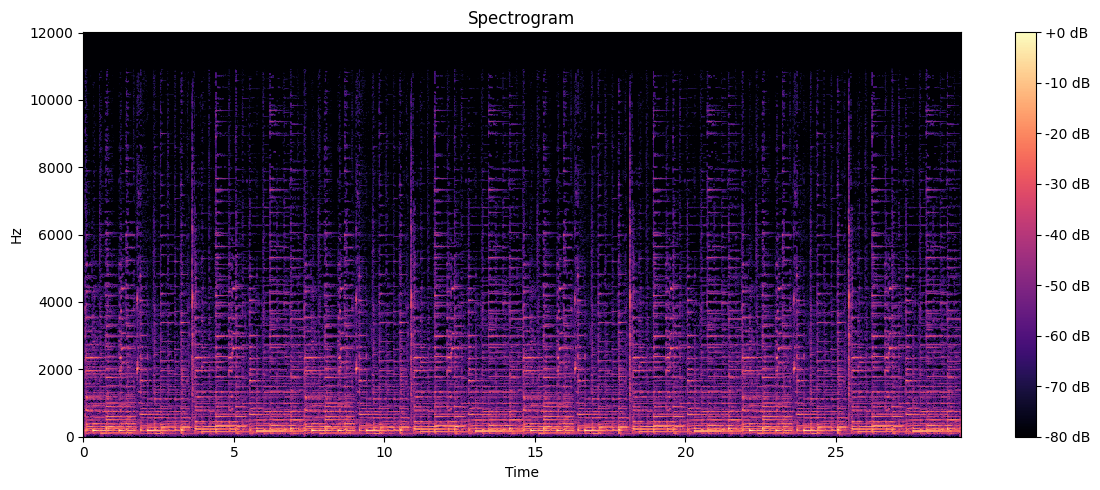

In [22]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.tight_layout()
plt.show()

Spectrograms are more informative than waveforms for audio analysis, as they reveal patterns such as harmonics, rhythms, and timbre.

In this example, most energy is concentrated in the lower frequency range, which is typical for many music signals.

## Observations

- The waveform illustrates how the signal amplitude evolves over time, highlighting variations in loudness.
- The spectrogram reveals how frequency components change over time.
- Brighter regions indicate higher energy at specific frequencies.
- Most energy is concentrated in lower frequencies, which is typical for many audio signals such as music or speech.
- Vertical patterns may indicate transient events or rhythmic structures (e.g., beats or percussive elements).

## Week 1 Summary

In this week, we built the foundation for working with audio data:

- Loaded and inspected an audio file
- Understood how audio is represented as a waveform
- Visualized the signal in the time domain
- Computed and plotted a spectrogram using STFT
- Gained first insights into the time–frequency structure of audio signals

These concepts form the basis for more advanced audio analysis tasks such as feature extraction and machine learning in the following weeks.